# AI Olympiad — Track 1: Build Your Own Mini LLM

## Your task

In this track, you build a language model **from scratch** — no pretrained
weights, no downloading someone else's GPT. You write/tune the tokenizer,
the Transformer architecture, and the training loop, then train it on text
you collect yourself. The person whose model **generates the best text**
wins the track.

"Best" here means: coherent, on-topic, grammatically sound generations —
not just low loss. Loss and perplexity are useful signals while you train,
but the actual judging is on the generated output.

- `bahrain_text.txt` is your training data. A small sample is included so
  the notebook runs end to end out of the box, but **you are expected to
  replace/expand it** with a much larger dataset you collect yourself —
  see Section 2 for what "collect from many sources" means in practice.
- Everything below is a **working sample pipeline**: tokenizer → dataset →
  model → train → evaluate → generate → save. It runs, but the model in
  it is just a baseline. You're free to change any parameter, swap in
  your own architecture, or rewrite training/generation entirely — as
  long as the model is still trained from scratch by you.

Run cells top to bottom. Everything you can tweak is marked `# TODO`.


In [ ]:
!pip install -q -U "tokenizers==0.23.1" tqdm matplotlib numpy


## 1. Get the MiniLLM framework

(`tokenizer.py`, `dataset.py`, `model.py`, `training.py`, `generation.py`)

These files hold the actual implementation (tokenizer training, dataset
batching, the Transformer model, the training loop, and text generation).
This notebook just calls into them. You can open and edit any of these
files directly — nothing here is off-limits, this is just a starting
point.


In [3]:
import sys, os
import torch
print("torch:", torch.__version__)
print("GPU available:", torch.cuda.is_available())

FRAMEWORK_DIR = "./"
if FRAMEWORK_DIR not in sys.path:
    sys.path.insert(0, FRAMEWORK_DIR)

from tokenizer import create_tokenizer, load_tokenizer
from dataset import prepare_dataset, split_dataset
from model import create_model, add_transformer_layer, save_model, load_model
from training import train, evaluate, get_device
from generation import generate

device = get_device()
print("Using device:", device)

torch: 2.3.0+cu121
GPU available: True
Using device: cuda


## 2. Dataset

Upload your own `bahrain_text.txt` (or any `.txt` dataset, 5MB–50MB recommended) to
`bahrain_text.txt`. A small sample file is included so this notebook
runs end to end out of the box — but a tiny sample file will only ever produce a
tiny, repetitive model. **Replacing it with a real dataset is most of the work
in this track.**

Collect text from **multiple sources**, not just one, and concatenate it all
into a single `.txt` file:

- Wikipedia articles/dumps on your topics of interest
- News articles, blog posts
- Books or long-form text in the public domain
- Government/tourism sites, if relevant to your theme
- Any other clean, readable text you have rights to use

A model trained on one narrow source tends to just memorize and repeat it.
Mixing several sources and genres generally gives more varied, coherent
generations. Keep an eye on **quality over raw size** — clean, well-written
text beats a huge pile of scraped noise.


In [4]:
DATASET_FILE = os.path.join(FRAMEWORK_DIR, "bahrain_text.txt")

with open(DATASET_FILE, encoding="utf-8") as f:
    raw_text = f.read()

print("characters:", len(raw_text))
print(raw_text[:300])

characters: 2582
Bahrain is an island country located in the Arabian Gulf. It is one of the smallest countries in the world by land area. The capital city of Bahrain is Manama, a modern city known for its skyline, souqs, and financial district.

Bahrain has a long history that stretches back thousands of years. It w


## 3. Build your tokenizer

This trains a BPE (byte-pair encoding) tokenizer on your dataset — it
learns which character sequences in your text are common enough to become
single subword tokens, rather than using a fixed dictionary.

`vocab_size` controls how many subword tokens your tokenizer learns.
Bigger vocab = tokens represent more text each (shorter sequences), but
needs more data to learn a good vocabulary and enlarges the model's
embedding/output layers.


In [5]:
VOCAB_SIZE = 5000  # TODO: experiment with vocabulary size

tokenizer = create_tokenizer(
    file=DATASET_FILE,
    vocab_size=VOCAB_SIZE,
    save_path=os.path.join(FRAMEWORK_DIR, "tokenizer.json"),
)
print("vocab size:", tokenizer.vocab_size)




vocab size: 594


In [6]:
sample = "Bahrain is beautiful"
ids = tokenizer.encode(sample)
print("encoded:", ids)
print("decoded:", tokenizer.decode(ids))

encoded: [307, 351, 311, 72, 464, 87, 76, 73, 320]
decoded: Bahrain is beautiful


## 4. Prepare training data

This slices your tokenized text into fixed-length training examples: for
every window of `context_length` tokens, the model learns to predict the
next one. `context_length` is how many tokens of history the model sees
before predicting the next token — longer context lets the model use more
history, but costs more memory/compute per step, and must stay ≤ 256 for
this competition.


In [7]:
CONTEXT_LENGTH = 128  # TODO: experiment with context length

all_tokens = tokenizer.encode(raw_text)
print("total tokens:", len(all_tokens))

full_dataset = prepare_dataset(all_tokens, context_length=CONTEXT_LENGTH)
train_dataset, val_dataset = split_dataset(full_dataset, train_ratio=0.9)
print("train examples:", len(train_dataset))
print("val examples:", len(val_dataset))

total tokens: 1083
train examples: 858
val examples: 96


## 5. Build your Transformer

This is where the model architecture is defined — the sample below is a
standard GPT-style decoder-only Transformer. `EMBEDDING_SIZE`, `LAYERS`,
and `HEADS` control its size and capacity. Together with `vocab_size` and
`context_length`, these determine your total parameter count — watch the
printed parameter count against the **~20M parameter limit**.

This is also the section where you're free to go beyond the sample: change
the architecture in `model.py` (different attention, normalization,
activation, positional encoding, etc.), not just the three numbers below.


In [8]:
EMBEDDING_SIZE = 256  # TODO
LAYERS = 6            # TODO
HEADS = 8              # TODO

model = create_model(
    vocab_size=tokenizer.vocab_size,
    embedding_size=EMBEDDING_SIZE,
    layers=LAYERS,
    heads=HEADS,
    context_length=CONTEXT_LENGTH,
)
print(f"parameters: {model.num_parameters():,}")

parameters: 4,923,904


Optionally add extra Transformer blocks on top of the base model:

```python
model = add_transformer_layer(model, attention_heads=HEADS)
```

Use this if you want to grow the model after building it, rather than
changing `LAYERS` above and rebuilding from scratch.


## 6. Train

Trains the model on `train_dataset` for `EPOCHS` passes over the data.
`LEARNING_RATE` and `BATCH_SIZE` are the two other main training knobs —
all three are fair game to tune. Training loss is tracked so you can plot
it below and see whether the model is actually learning.


In [9]:
EPOCHS = 20          # TODO
LEARNING_RATE = 3e-4  # TODO
BATCH_SIZE = 32        # TODO

history = train(
    model,
    train_dataset,
    epochs=EPOCHS,
    learning_rate=LEARNING_RATE,
    batch_size=BATCH_SIZE,
    device=device,
)

Epoch 1/20:   0%|          | 0/26 [00:00<?, ?it/s]

Epoch 1/20 - loss: 5.6243 - perplexity: 277.07


Epoch 2/20:   0%|          | 0/26 [00:00<?, ?it/s]

Epoch 2/20 - loss: 4.4758 - perplexity: 87.86


Epoch 3/20:   0%|          | 0/26 [00:00<?, ?it/s]

...

Epoch 18/20 - loss: 0.0361 - perplexity: 1.04


Epoch 19/20:   0%|          | 0/26 [00:00<?, ?it/s]

Epoch 19/20 - loss: 0.0344 - perplexity: 1.03


Epoch 20/20:   0%|          | 0/26 [00:00<?, ?it/s]

Epoch 20/20 - loss: 0.0358 - perplexity: 1.04


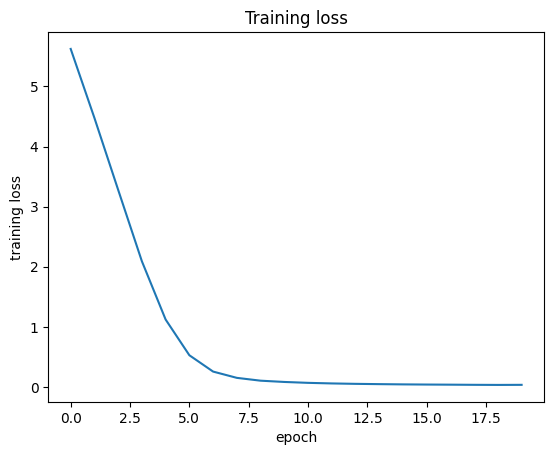

In [10]:
import matplotlib.pyplot as plt

plt.plot(history)
plt.xlabel("epoch")
plt.ylabel("training loss")
plt.title("Training loss")
plt.show()

## 7. Evaluate

Runs the model on `val_dataset` (data it never trained on) and reports
loss and **perplexity** — roughly, how "surprised" the model is by real
text, on average, per token. Lower is better. This is a useful sanity
check while iterating, but remember: the track is ultimately judged on
generated text quality, not this number alone.


In [11]:
metrics = evaluate(model, val_dataset, batch_size=BATCH_SIZE, device=device)
print(f"Loss: {metrics['loss']:.4f}")
print(f"Perplexity: {metrics['perplexity']:.2f}")

Loss: 0.0418
Perplexity: 1.04


## 8. Generate text

Samples text from your trained model given a starting prompt. `temperature`
and `top_k` control how random vs. predictable the output is — lower
temperature/top_k gives safer, more repetitive text; higher gives more
variety but risks incoherence. This is the actual output your model will
be judged on, so it's worth trying several prompts and settings here.


In [12]:
output = generate(
    model,
    tokenizer,
    prompt="Bahrain is",
    max_tokens=100,
    temperature=0.8,
    top_k=40,
    device=device,
)
print(output)

Bahrain is connected to Saudi Arabia by the King Fahd Causeway, a bridge that allows road travel between the two countries. The Bahrain International Circuit hosts a Formula One Grand Prix every year, attracting visitors


## 9. Save your submission

Saves your trained model weights and tokenizer to disk. Both files
(`my_llm.pt` and `tokenizer.json`) are what you submit — make sure the
final cell below (reload + generate) runs cleanly on them before
submitting, since that's exactly how your submission will be checked.


In [13]:
MODEL_PATH = os.path.join(FRAMEWORK_DIR, "my_llm.pt")
save_model(model, MODEL_PATH, heads=HEADS)
print("saved:", MODEL_PATH)
print("tokenizer:", os.path.join(FRAMEWORK_DIR, "tokenizer.json"))

saved: ./my_llm.pt
tokenizer: ./tokenizer.json


In [17]:
loaded_model = load_model(MODEL_PATH)
loaded_tokenizer = load_tokenizer(os.path.join(FRAMEWORK_DIR, "tokenizer.json"))

print(generate(loaded_model, loaded_tokenizer, prompt="Bahrain is ", max_tokens=60, device=device))

Bahrain is King Fahd Causeway, a bridge that allows road travel between the two countries. The Bahrain International Circuit hosts a Form
